In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Path to dataset files: /kaggle/input/gtzan-dataset-music-genre-classification


In [5]:
import os

# 1. Check what's inside the downloaded path
print(f"Dataset downloaded to: {path}")
print("Contents:", os.listdir(path))

# 2. Set the correct path for the processing function
# The dataset usually extracts into a folder named 'Data' or directly contains 'genres_original'
possible_path = os.path.join(path, "Data", "genres_original")

if os.path.exists(possible_path):
    DATA_PATH = possible_path
else:
    # Fallback if structure is different
    DATA_PATH = os.path.join(path, "genres_original")

print(f"Processing audio from: {DATA_PATH}")

# 3. Now run the MFCC extraction function we defined earlier
# save_mfcc(DATA_PATH, "data.json", num_segments=10)

Dataset downloaded to: /kaggle/input/gtzan-dataset-music-genre-classification
Contents: ['Data']
Processing audio from: /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original


In [8]:
import os
import json
import math
import librosa
import numpy as np

# 1. SET THE PATH DIRECTLY (Based on your previous success log)
DATA_PATH = "/root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original"

# Verify it exists before proceeding
if not os.path.exists(DATA_PATH):
    print(f"❌ Error: Path not found at {DATA_PATH}")
    # Fallback: Try downloading again to get a fresh path
    import kagglehub
    print("Redownloading to ensure path is correct...")
    path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
    DATA_PATH = os.path.join(path, "Data", "genres_original")
    print(f"New Path: {DATA_PATH}")

print(f"✅ Processing audio from: {DATA_PATH}")

# 2. DEFINE EXTRACTION FUNCTION
JSON_PATH = "data.json"
SAMPLE_RATE = 22050
TRACK_DURATION = 30 # Seconds
SAMPLES_PER_TRACK = SAMPLE_RATE * TRACK_DURATION

def save_mfcc(dataset_path, json_path, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10):
    """Extracts MFCCs from music dataset and saves them into a JSON file."""
    data = {
        "mapping": [],
        "labels": [],
        "mfcc": []
    }

    samples_per_segment = int(SAMPLES_PER_TRACK / num_segments)
    num_mfcc_vectors_per_segment = math.ceil(samples_per_segment / hop_length)

    print("🚀 Starting Feature Extraction...")

    # Loop through all genre sub-folders
    for i, (dirpath, dirnames, filenames) in enumerate(os.walk(dataset_path)):

        # Ensure we're processing a genre sub-folder level
        if dirpath is not dataset_path:

            # Save genre label (e.g., 'blues')
            semantic_label = dirpath.split("/")[-1]
            data["mapping"].append(semantic_label)
            print(f"   Processing Genre: {semantic_label}")

            # Process all audio files in genre sub-dir
            for f in filenames:
                file_path = os.path.join(dirpath, f)

                # Skip non-audio files
                if not file_path.endswith('.wav'): continue

                try:
                    # Load audio
                    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

                    # Process segments
                    for d in range(num_segments):
                        start = samples_per_segment * d
                        finish = start + samples_per_segment

                        # Extract MFCC
                        mfcc = librosa.feature.mfcc(y=signal[start:finish], sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
                        mfcc = mfcc.T

                        # Store only mfcc feature with expected number of vectors
                        if len(mfcc) == num_mfcc_vectors_per_segment:
                            data["mfcc"].append(mfcc.tolist())
                            data["labels"].append(i-1) # i-1 because enumerate counts the root folder as 0

                except Exception as e:
                    print(f"   ⚠️ Error processing {f}: {e}")

    # Save to JSON
    with open(json_path, "w") as fp:
        json.dump(data, fp, indent=4)

    print(f"\n✅ SUCCESS! Features saved to {json_path}")

# 3. RUN EXTRACTION
save_mfcc(DATA_PATH, JSON_PATH, num_segments=10)

❌ Error: Path not found at /root/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original
Redownloading to ensure path is correct...
Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
New Path: /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original
✅ Processing audio from: /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original
🚀 Starting Feature Extraction...
   Processing Genre: disco
   Processing Genre: metal
   Processing Genre: reggae
   Processing Genre: blues
   Processing Genre: rock
   Processing Genre: classical
   Processing Genre: jazz


/tmp/ipython-input-374/3498940574.py:61: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


   ⚠️ Error processing jazz.00054.wav: 
   Processing Genre: hiphop
   Processing Genre: country
   Processing Genre: pop

✅ SUCCESS! Features saved to data.json


Loading data...
Data Loaded. Training Shape: (7988, 130, 13, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting Training...
Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.2070 - loss: 2.4802 - val_accuracy: 0.3944 - val_loss: 1.7705
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3849 - loss: 1.8017 - val_accuracy: 0.4720 - val_loss: 1.5291
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4464 - loss: 1.6109 - val_accuracy: 0.5100 - val_loss: 1.4121
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4933 - loss: 1.4525 - val_accuracy: 0.5335 - val_loss: 1.3151
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5208 - loss: 1.3557 - val_accuracy: 0.5531 - val_loss: 1.2551
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5333 - loss: 1.3020 - val_accuracy: 0.5681 - val_loss: 1.2058
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5475 - loss: 1.2528 - val_accuracy: 0.5946 - val_loss: 1.1443
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5728 - loss: 1.

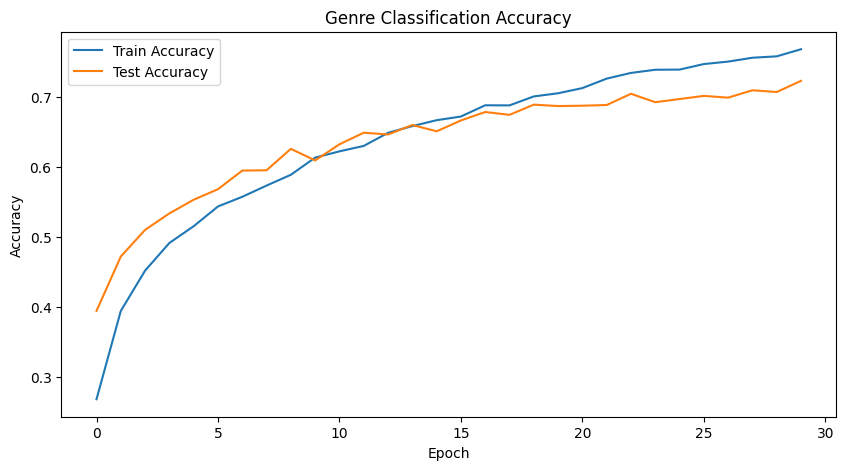

Model saved as music_genre_cnn.h5


In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization

# --- 1. Load Data ---
def load_data(dataset_path):
    with open(dataset_path, "r") as fp:
        data = json.load(fp)

    # Convert lists to numpy arrays
    inputs = np.array(data["mfcc"])
    targets = np.array(data["labels"])
    mapping = data["mapping"]

    return inputs, targets, mapping

# Load the JSON file created in the previous step
print("Loading data...")
X, y, mapping = load_data("data.json")

# --- 2. Prepare Data ---
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape for CNN (add the channel dimension, like grayscale images)
# Shape: (Num_Samples, Time_Bins, MFCC_Bins, Channels)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Data Loaded. Training Shape: {X_train.shape}")

# --- 3. Build CNN Model ---
input_shape = (X_train.shape[1], X_train.shape[2], 1)

model = Sequential()

# 1st Conv Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
model.add(BatchNormalization())

# 2nd Conv Layer
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
model.add(BatchNormalization())

# 3rd Conv Layer
model.add(Conv2D(32, (2, 2), activation='relu'))
model.add(MaxPooling2D((2, 2), strides=(2, 2), padding='same'))
model.add(BatchNormalization())

# Flatten & Dense
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output Layer (10 Genres)
model.add(Dense(10, activation='softmax'))

# --- 4. Compile & Train ---
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Starting Training...")
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=30,
                    batch_size=32)

# --- 5. Plot Results ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Genre Classification Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# --- 6. Save Model ---
model.save("music_genre_cnn.h5")
print("Model saved as music_genre_cnn.h5")

In [11]:
from collections import Counter

def predict_genre_voting(file_path, model):
    """
    Slices the WHOLE song into 10 segments, predicts each, and takes the majority vote.
    """
    # 1. Load Audio
    signal, sr = librosa.load(file_path, sr=22050, duration=30)

    # Calculate samples per segment (same as training)
    samples_per_segment = int(22050 * 30 / 10)
    num_mfcc_vectors_per_segment = math.ceil(samples_per_segment / 512)

    predictions = []

    # 2. Loop through all 10 segments
    for d in range(10):
        start = samples_per_segment * d
        finish = start + samples_per_segment

        # Extract MFCC
        mfcc = librosa.feature.mfcc(y=signal[start:finish], sr=sr, n_mfcc=13, n_fft=2048, hop_length=512)
        mfcc = mfcc.T

        # Check shape matches training data
        if len(mfcc) == num_mfcc_vectors_per_segment:
            mfcc = mfcc[np.newaxis, ..., np.newaxis] # Reshape to (1, 130, 13, 1)

            # Predict
            pred = model.predict(mfcc, verbose=0)
            pred_index = np.argmax(pred, axis=1)[0]
            predictions.append(mapping[pred_index])

    # 3. Majority Vote
    # Count the votes (e.g., ['jazz', 'jazz', 'country', 'jazz'...])
    vote_counts = Counter(predictions)
    winner = vote_counts.most_common(1)[0][0]

    return winner, vote_counts

# --- RETEST ---
print(f"🎵 Retesting file: {song}")
print(f"   Actual Genre: {genre}")

winner, votes = predict_genre_voting(test_file_path, model)

print(f"\n🗳️ Voting Results: {votes}")
print(f"🤖 Final Prediction: {winner.upper()}")

if genre == winner:
    print("✅ Correct!")
else:
    print("❌ Incorrect.")

🎵 Retesting file: jazz.00050.wav
   Actual Genre: jazz

🗳️ Voting Results: Counter({'jazz': 5, 'country': 3, 'rock': 2})
🤖 Final Prediction: JAZZ
✅ Correct!
